1. Импорты 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('Set2')

print("Библиотеки загружены!")

Библиотеки загружены!


2. Генерация данных

In [3]:
np.random.seed(42)

n_products = 100
n_days = 90

print(f"Генерируем {n_products} товаров × {n_days} дней = {n_products * n_days} записей")

dates = pd.date_range('2024-01-01', periods=n_days, freq='D')

data = []
for product_id in range(n_products):
    base_price = np.random.uniform(500, 5000)
    category = np.random.choice(['электроника', 'бытовая техника', 'аксессуары'])
    
    for day, date in enumerate(dates):
        season_effect = np.sin(day * 2 * np.pi / 30) * base_price * 0.1
        noise = np.random.normal(0, base_price * 0.05)
        competitor_price = base_price + season_effect + noise
        our_price = competitor_price + np.random.normal(0, base_price * 0.03)
        demand_index = int(np.clip(100 - (our_price - base_price) / base_price * 100 + np.random.normal(0, 10), 50, 150))
        stock_level = np.random.randint(10, 1000)
        margin = np.random.uniform(0.1, 0.4)
        optimal_price = base_price * (1 + (demand_index - 100) / 1000 + margin * 0.1)
        
        data.append({
            'product_id': product_id,
            'date': date,
            'category': category,
            'competitor_price': round(competitor_price, 2),
            'our_price': round(our_price, 2),
            'demand_index': demand_index,
            'stock_level': stock_level,
            'margin': round(margin, 3),
            'optimal_price': round(optimal_price, 2)
        })

df = pd.DataFrame(data)
print(f"Датасет создан: {df.shape[0]} строк, {df.shape[1]} колонок")
df.head()

Генерируем 100 товаров × 90 дней = 9000 записей
Датасет создан: 9000 строк, 9 колонок


,product_id,date,category,competitor_price,our_price,demand_index,stock_level,margin,optimal_price
0,0,2024-01-01,электроника,2244.85,2204.50,87,224,0.117,2182.68
1,0,2024-01-02,электроника,2464.89,2483.19,96,673,0.295,2241.22
2,0,2024-01-03,электроника,2283.04,2272.58,96,520,0.142,2207.69
3,0,2024-01-04,электроника,2267.14,2207.61,84,199,0.127,2178.26
4,0,2024-01-05,электроника,2186.52,2284.01,95,494,0.282,2236.19


3. Информация о данных

In [4]:
print("=" * 50)
print("ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 50)
df.info()

print("\nСТАТИСТИКИ:")
df.describe()

ИНФОРМАЦИЯ О ДАТАСЕТЕ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   product_id        9000 non-null   int64         
 1   date              9000 non-null   datetime64[ns]
 2   category          9000 non-null   object        
 3   competitor_price  9000 non-null   float64       
 4   our_price         9000 non-null   float64       
 5   demand_index      9000 non-null   int64         
 6   stock_level       9000 non-null   int64         
 7   margin            9000 non-null   float64       
 8   optimal_price     9000 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(1)
memory usage: 632.9+ KB

СТАТИСТИКИ:


,product_id,date,competitor_price,our_price,demand_index,stock_level,margin,optimal_price
count,9000.000000,9000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,49.500000,2024-02-14 12:00:00,2739.365526,2740.562424,99.291333,508.826222,0.250024,2806.217213
min,0.000000,2024-01-01 00:00:00,373.990000,378.250000,50.000000,10.000000,0.100000,493.610000
25%,24.750000,2024-01-23 00:00:00,1617.950000,1615.637500,90.000000,265.000000,0.173000,1703.345000
50%,49.500000,2024-02-14 12:00:00,2662.785000,2662.725000,99.000000,512.500000,0.251500,2742.865000
75%,74.250000,2024-03-08 00:00:00,3842.700000,3846.422500,109.000000,755.000000,0.325000,4021.237500
max,99.000000,2024-03-30 00:00:00,5935.310000,6177.690000,149.000000,999.000000,0.400000,5312.340000
std,28.867674,NaN,1324.464229,1329.224465,13.778719,284.532165,0.086813,1329.813297


4. Проверка пропусков

In [5]:
print("Пропуски:", df.isnull().sum().sum())
print("Дубликаты:", df.duplicated().sum())
print("Уникальных товаров:", df['product_id'].nunique())
print("Категории:", list(df['category'].unique()))

Пропуски: 0
Дубликаты: 0
Уникальных товаров: 100
Категории: [np.str_('электроника'), np.str_('аксессуары'), np.str_('бытовая техника')]


5. Гистограммы цен

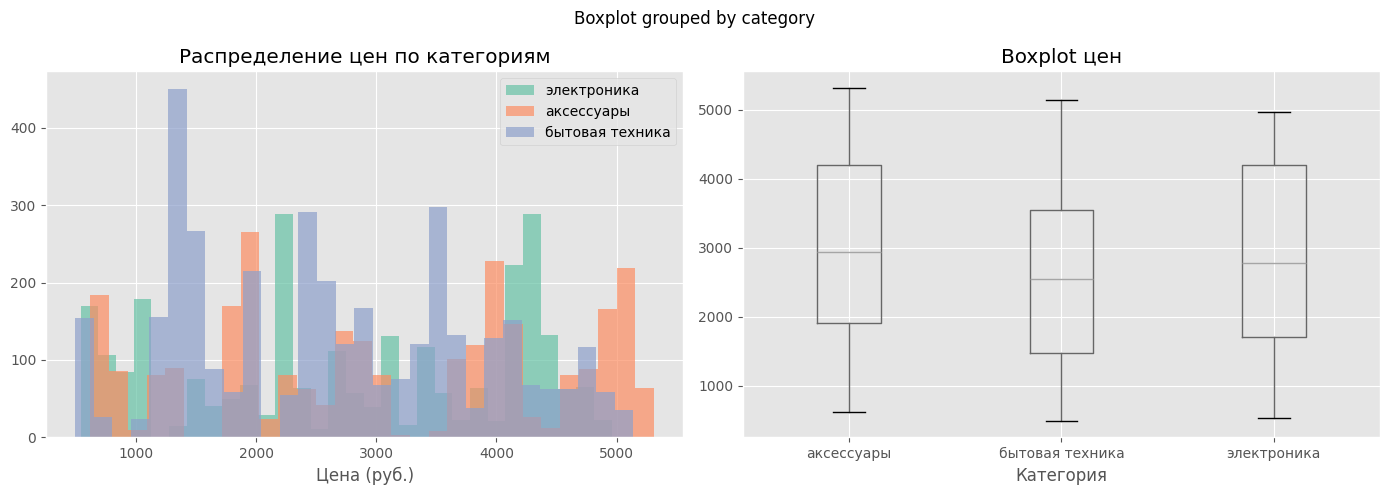

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cat in df['category'].unique():
    subset = df[df['category'] == cat]['optimal_price']
    axes[0].hist(subset, alpha=0.7, label=cat, bins=30)
axes[0].set_title('Распределение цен по категориям')
axes[0].set_xlabel('Цена (руб.)')
axes[0].legend()

df.boxplot(column='optimal_price', by='category', ax=axes[1])
axes[1].set_title('Boxplot цен')
axes[1].set_xlabel('Категория')

plt.tight_layout()
plt.show()

6. Корреляции

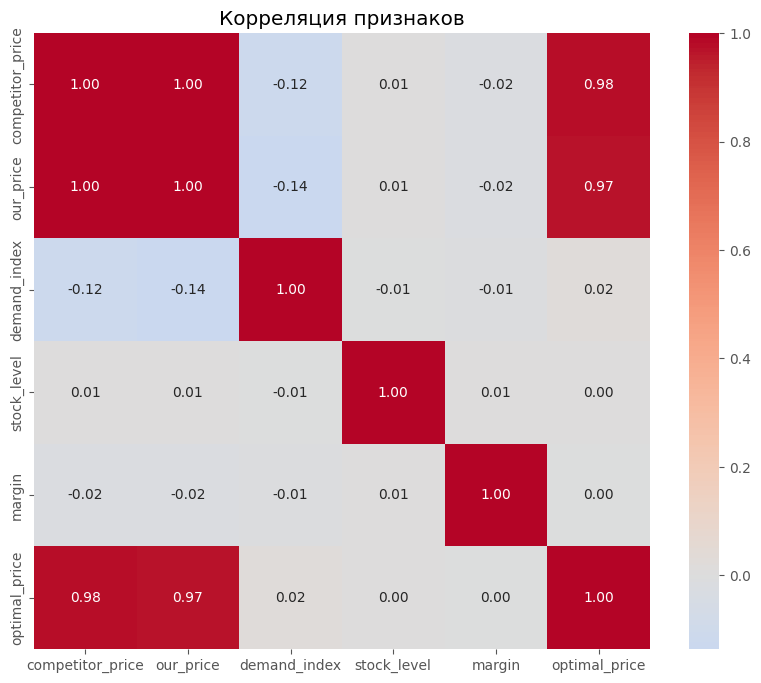

Корреляция с optimal_price:
optimal_price       1.000000
competitor_price    0.975359
our_price           0.972610
demand_index        0.019458
stock_level         0.004316
margin              0.001284
Name: optimal_price, dtype: float64


In [7]:
numeric_cols = ['competitor_price', 'our_price', 'demand_index', 'stock_level', 'margin', 'optimal_price']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Корреляция признаков')
plt.show()

print("Корреляция с optimal_price:")
print(corr['optimal_price'].sort_values(ascending=False))

7. Динамика цен

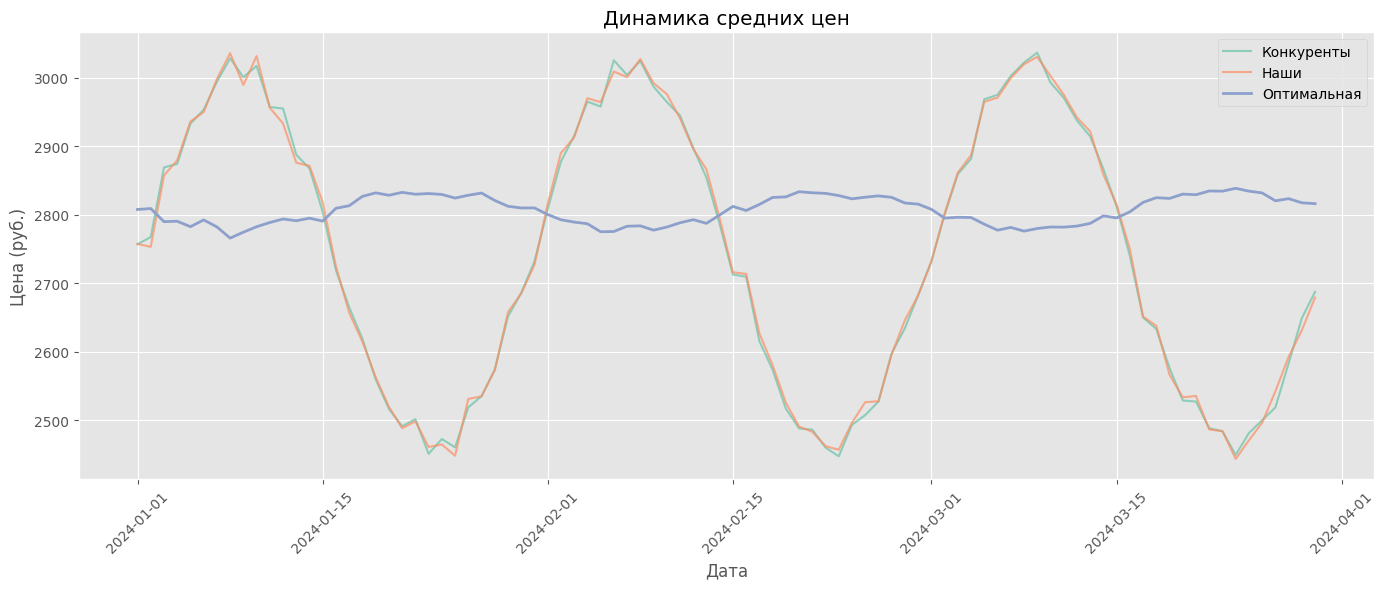

In [8]:
daily = df.groupby('date')[['competitor_price', 'our_price', 'optimal_price']].mean()

plt.figure(figsize=(14, 6))
plt.plot(daily.index, daily['competitor_price'], label='Конкуренты', alpha=0.7)
plt.plot(daily.index, daily['our_price'], label='Наши', alpha=0.7)
plt.plot(daily.index, daily['optimal_price'], label='Оптимальная', linewidth=2)
plt.title('Динамика средних цен')
plt.xlabel('Дата')
plt.ylabel('Цена (руб.)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

8. Сохранение данных

In [9]:
save_path = '../data/sample_data.csv'
df.to_csv(save_path, index=False)
print(f"Данные сохранены: {save_path}")
print(f"Размер: {df.shape[0]} строк × {df.shape[1]} колонок")

Данные сохранены: ../data/sample_data.csv
Размер: 9000 строк × 9 колонок
